# House Price Prediction using Ridge and Lasso Regression
## Machine Learning Assignment by Praveen Chand

**Course**: SAP Labs India - EPGPMLAI Program  
**Date**: January 2026  
**Dataset**: Ames Housing Data (1,460 properties, price range: $34,900 - $755,000)

## Problem Statement
Surprise Housing, a US-based company, wants to enter the Australian housing market. They use data analytics to purchase houses below their actual values and flip them at higher prices. This project builds a regression model using regularization techniques to predict house prices and identify significant variables.

**My Approach**: I will implement both Ridge and Lasso regression with cross-validation to find the optimal regularization parameters and identify the most significant features for house price prediction.

## Business Objectives
1. Identify variables significant in predicting house prices
2. Determine how well these variables describe house prices
3. Find optimal lambda values for Ridge and Lasso regression
4. Help management understand pricing dynamics in the new market

## 1. Data Import and Setup

In [3]:
# Importing necessary libraries for my house price prediction analysis
# Author: Praveen Chand - SAP Labs EPGPMLAI Program
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import Ridge, Lasso, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.feature_selection import RFE
import warnings
warnings.filterwarnings('ignore')  # Suppressing warnings for cleaner output


pd.set_option('display.max_columns', None)
plt.style.use('ggplot')  # I prefer this plotting style for better visualization
sns.set_palette("husl")  # Colorful palette for better distinction in plots

print("Libraries imported successfully! Ready to begin analysis.")

Libraries imported successfully! Ready to begin analysis.


In [4]:
# Load the dataset
df = pd.read_csv('train.csv')
print(f"Dataset shape: {df.shape}")
print("\nFirst few rows:")
df.head()

Dataset shape: (1460, 81)

First few rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


## 2. Exploratory Data Analysis (EDA)

In [5]:
# Basic information about the dataset
print("Dataset Info:")
print(f"Shape: {df.shape}")
print(f"\nData types:")
print(df.dtypes.value_counts())
print(f"\nTarget variable (SalePrice) statistics:")
print(df['SalePrice'].describe())

Dataset Info:
Shape: (1460, 81)

Data types:
object     43
int64      35
float64     3
Name: count, dtype: int64

Target variable (SalePrice) statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


In [6]:
# Check for missing values
missing_data = df.isnull().sum()
missing_data = missing_data[missing_data > 0].sort_values(ascending=False)
missing_percentage = (missing_data / len(df)) * 100

print("Missing values analysis:")
missing_df = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentage
})
print(missing_df.head(20))

Missing values analysis:
              Missing Count  Missing Percentage
PoolQC                 1453           99.520548
MiscFeature            1406           96.301370
Alley                  1369           93.767123
Fence                  1179           80.753425
MasVnrType              872           59.726027
FireplaceQu             690           47.260274
LotFrontage             259           17.739726
GarageType               81            5.547945
GarageYrBlt              81            5.547945
GarageFinish             81            5.547945
GarageQual               81            5.547945
GarageCond               81            5.547945
BsmtFinType2             38            2.602740
BsmtExposure             38            2.602740
BsmtFinType1             37            2.534247
BsmtCond                 37            2.534247
BsmtQual                 37            2.534247
MasVnrArea                8            0.547945
Electrical                1            0.068493


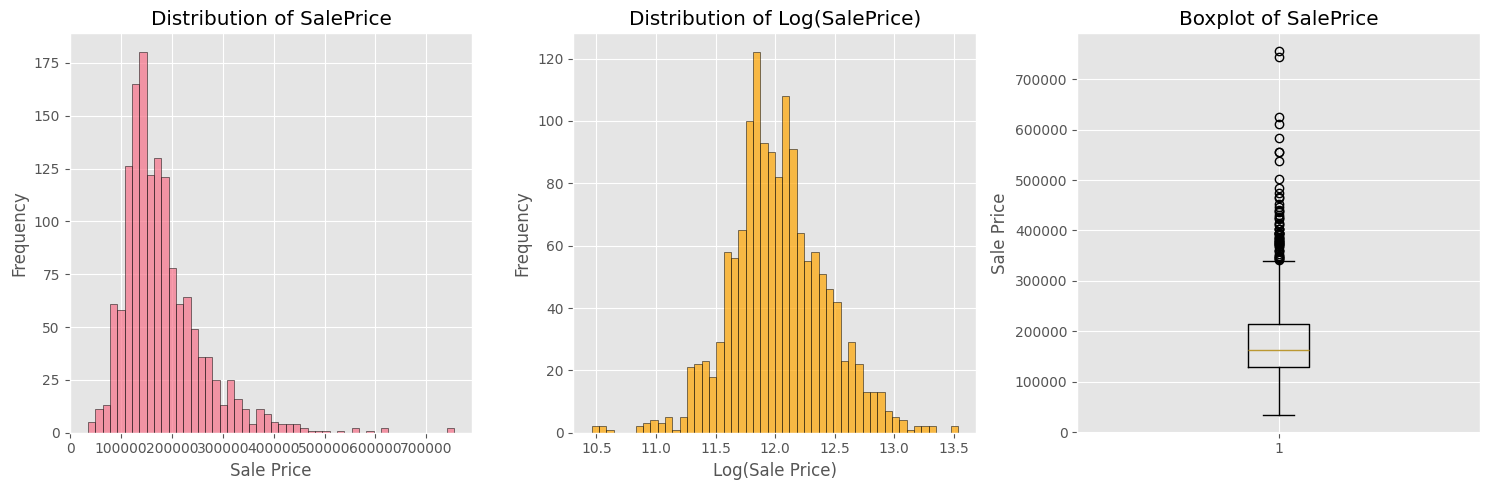

Skewness of SalePrice: 1.883
Skewness of Log(SalePrice): 0.121


In [7]:
# Visualizing the target variable distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.hist(df['SalePrice'], bins=50, edgecolor='black', alpha=0.7)
plt.title('Distribution of SalePrice')
plt.xlabel('Sale Price')
plt.ylabel('Frequency')

plt.subplot(1, 3, 2)
plt.hist(np.log(df['SalePrice']), bins=50, edgecolor='black', alpha=0.7, color='orange')
plt.title('Distribution of Log(SalePrice)')
plt.xlabel('Log(Sale Price)')
plt.ylabel('Frequency')

plt.subplot(1, 3, 3)
plt.boxplot(df['SalePrice'])
plt.title('Boxplot of SalePrice')
plt.ylabel('Sale Price')

plt.tight_layout()
plt.show()

print(f"Skewness of SalePrice: {df['SalePrice'].skew():.3f}")
print(f"Skewness of Log(SalePrice): {np.log(df['SalePrice']).skew():.3f}")

In [8]:
# Correlation analysis with target variable
numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
correlation_with_target = df[numeric_features].corr()['SalePrice'].sort_values(ascending=False)

print("Top 15 features most correlated with SalePrice:")
print(correlation_with_target.head(16)[1:])

print("\nBottom 10 features least correlated with SalePrice:")
print(correlation_with_target.tail(10))

Top 15 features most correlated with SalePrice:
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
GarageYrBlt     0.486362
MasVnrArea      0.477493
Fireplaces      0.466929
BsmtFinSF1      0.386420
LotFrontage     0.351799
Name: SalePrice, dtype: float64

Bottom 10 features least correlated with SalePrice:
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePrice, dtype: float64


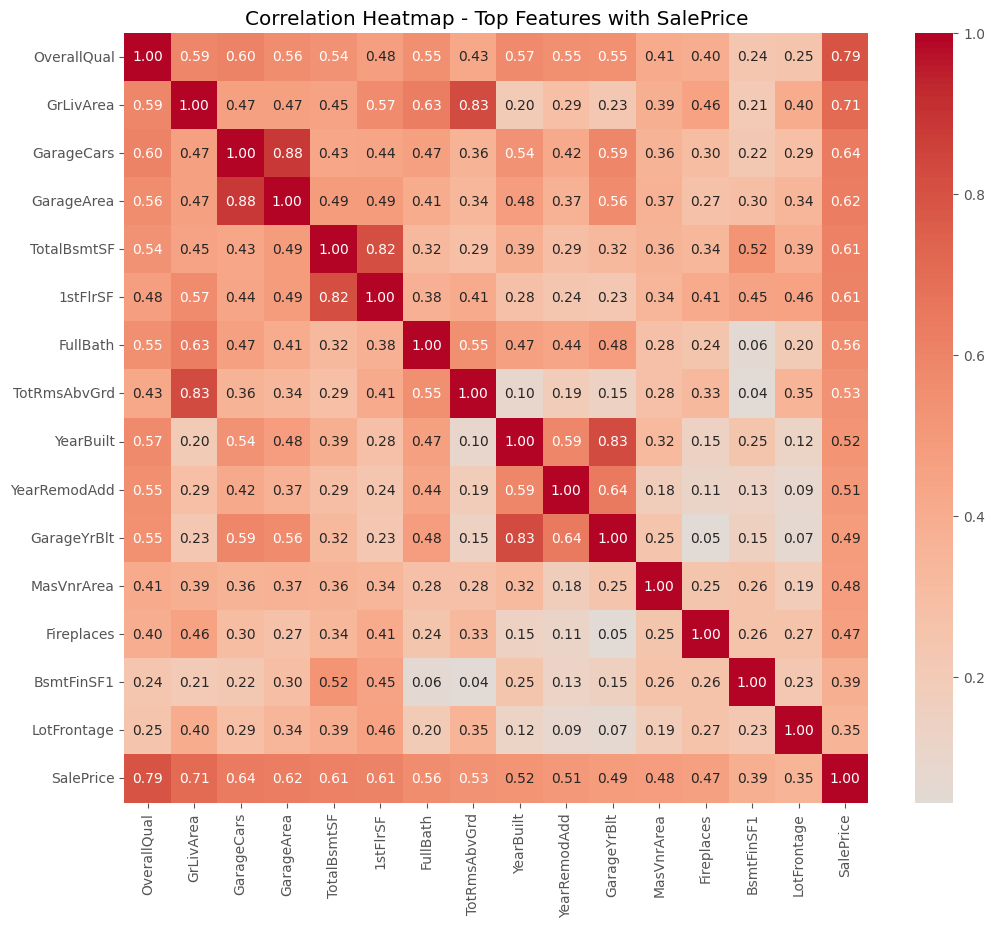

In [9]:
# Visualizing correlation heatmap for top features
top_features = correlation_with_target.head(16)[1:].index.tolist() + ['SalePrice']
plt.figure(figsize=(12, 10))
correlation_matrix = df[top_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Heatmap - Top Features with SalePrice')
plt.show()

## 3. Data Preprocessing

In [10]:
# Creating a copy for preprocessing
df_processed = df.copy()

# Logging transform the target variable to reduce skewness
df_processed['SalePrice_log'] = np.log(df_processed['SalePrice'])

print(f"Original SalePrice skewness: {df_processed['SalePrice'].skew():.3f}")
print(f"Log-transformed SalePrice skewness: {df_processed['SalePrice_log'].skew():.3f}")

Original SalePrice skewness: 1.883
Log-transformed SalePrice skewness: 0.121


In [11]:
# Handling missing values strategically
# For categorical variables with 'NA' meaning 'None' (based on data description)
categorical_na_cols = ['Alley', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
                      'FireplaceQu', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
                      'PoolQC', 'Fence', 'MiscFeature']

for col in categorical_na_cols:
    if col in df_processed.columns:
        df_processed[col].fillna('None', inplace=True)

# For LotFrontage, fill with median based on neighborhood
df_processed['LotFrontage'] = df_processed.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median()))

# For GarageYrBlt, fill with YearBuilt
df_processed['GarageYrBlt'].fillna(df_processed['YearBuilt'], inplace=True)

# For MasVnrType and MasVnrArea
df_processed['MasVnrType'].fillna('None', inplace=True)
df_processed['MasVnrArea'].fillna(0, inplace=True)

# Fill remaining missing values
# Categorical with mode
categorical_cols = df_processed.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].mode()[0], inplace=True)

# Numerical with median
numerical_cols = df_processed.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    if df_processed[col].isnull().sum() > 0:
        df_processed[col].fillna(df_processed[col].median(), inplace=True)

print(f"Missing values after preprocessing: {df_processed.isnull().sum().sum()}")

Missing values after preprocessing: 0


In [10]:
# Creating new features based on domain knowledge
# Total square footage
df_processed['TotalSF'] = df_processed['1stFlrSF'] + df_processed['2ndFlrSF'] + df_processed['TotalBsmtSF']

# Total bathrooms
df_processed['TotalBath'] = df_processed['FullBath'] + (0.5 * df_processed['HalfBath']) + df_processed['BsmtFullBath'] + (0.5 * df_processed['BsmtHalfBath'])

# House age
df_processed['HouseAge'] = df_processed['YrSold'] - df_processed['YearBuilt']

# Years since remodel
df_processed['YearsSinceRemodel'] = df_processed['YrSold'] - df_processed['YearRemodAdd']

print("New features created:")
print("- TotalSF: Total square footage")
print("- TotalBath: Total number of bathrooms")
print("- HouseAge: Age of the house when sold")
print("- YearsSinceRemodel: Years since last remodel")

New features created:
- TotalSF: Total square footage
- TotalBath: Total number of bathrooms
- HouseAge: Age of the house when sold
- YearsSinceRemodel: Years since last remodel


In [12]:
# Handling categorical variables - Creating dummy variables
categorical_features = df_processed.select_dtypes(include=['object']).columns.tolist()
print(f"Number of categorical features: {len(categorical_features)}")

# Creating dummy variables
df_dummies = pd.get_dummies(df_processed, columns=categorical_features, drop_first=True)
print(f"Shape after creating dummy variables: {df_dummies.shape}")

Number of categorical features: 43
Shape after creating dummy variables: (1460, 262)


In [13]:
# Preparing features and target
# Droping unnecessary columns
drop_cols = ['Id', 'SalePrice']
X = df_dummies.drop(drop_cols + ['SalePrice_log'], axis=1)
y = df_dummies['SalePrice_log']  # Using log-transformed target

print(f"Feature matrix shape: {X.shape}")
print(f"Target vector shape: {y.shape}")
print(f"Number of features: {X.shape[1]}")

Feature matrix shape: (1460, 259)
Target vector shape: (1460,)
Number of features: 259


## 4. Feature Selection and Scaling

In [14]:
# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (1168, 259)
Test set shape: (292, 259)


In [15]:
# Scaling the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Features scaled successfully!")
print(f"Mean of first feature after scaling: {X_train_scaled[:, 0].mean():.3f}")
print(f"Std of first feature after scaling: {X_train_scaled[:, 0].std():.3f}")

Features scaled successfully!
Mean of first feature after scaling: 0.000
Std of first feature after scaling: 1.000


## 5. Model Building and Evaluation

### 5.1 Baseline Linear Regression

In [16]:
# Baseline Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

# Predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# Evaluate
lr_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
lr_r2 = r2_score(y_test, y_pred_lr)
lr_mae = mean_absolute_error(y_test, y_pred_lr)

print("Baseline Linear Regression Performance:")
print(f"RMSE: {lr_rmse:.4f}")
print(f"R²: {lr_r2:.4f}")
print(f"MAE: {lr_mae:.4f}")

Baseline Linear Regression Performance:
RMSE: 0.1739
R²: 0.8379
MAE: 0.0962


### 5.2 Ridge Regression with Cross-Validation

In [17]:
# Ridge Regression - Hyperparameter tuning
ridge_alphas = np.logspace(-3, 3, 100)
ridge_model = Ridge()

# Grid search with cross-validation
ridge_grid = GridSearchCV(ridge_model, {'alpha': ridge_alphas}, 
                         cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
ridge_grid.fit(X_train_scaled, y_train)

print(f"Best Ridge alpha: {ridge_grid.best_params_['alpha']:.4f}")
print(f"Best Ridge CV score (neg MSE): {ridge_grid.best_score_:.4f}")

# Best Ridge model
best_ridge = ridge_grid.best_estimator_
y_pred_ridge = best_ridge.predict(X_test_scaled)

# Evaluate Ridge
ridge_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
ridge_r2 = r2_score(y_test, y_pred_ridge)
ridge_mae = mean_absolute_error(y_test, y_pred_ridge)

print(f"\nRidge Regression Performance:")
print(f"RMSE: {ridge_rmse:.4f}")
print(f"R²: {ridge_r2:.4f}")
print(f"MAE: {ridge_mae:.4f}")

Best Ridge alpha: 572.2368
Best Ridge CV score (neg MSE): -0.0234

Ridge Regression Performance:
RMSE: 0.1538
R²: 0.8733
MAE: 0.1000


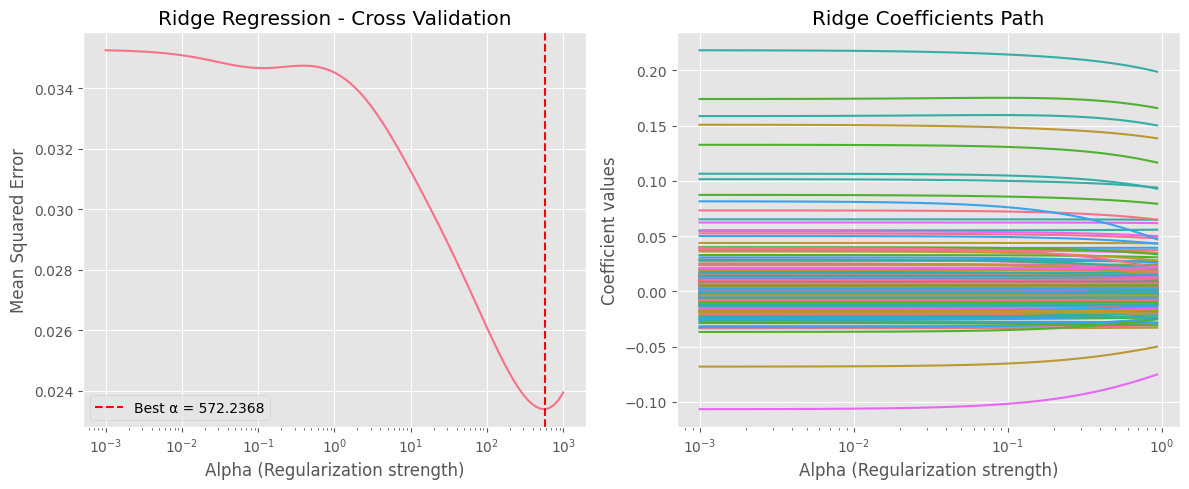

In [18]:
# Visualizing Ridge regularization path
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(ridge_alphas, [-score for score in ridge_grid.cv_results_['mean_test_score']])
plt.axvline(ridge_grid.best_params_['alpha'], color='red', linestyle='--', label=f"Best α = {ridge_grid.best_params_['alpha']:.4f}")
plt.xscale('log')
plt.xlabel('Alpha (Regularization strength)')
plt.ylabel('Mean Squared Error')
plt.title('Ridge Regression - Cross Validation')
plt.legend()
plt.grid(True)

# Ridge coefficients path
plt.subplot(1, 2, 2)
ridge_coefs = []
for alpha in ridge_alphas[:50]:  # Use subset for visualization
    ridge_temp = Ridge(alpha=alpha)
    ridge_temp.fit(X_train_scaled, y_train)
    ridge_coefs.append(ridge_temp.coef_)

plt.plot(ridge_alphas[:50], ridge_coefs)
plt.xscale('log')
plt.xlabel('Alpha (Regularization strength)')
plt.ylabel('Coefficient values')
plt.title('Ridge Coefficients Path')
plt.grid(True)

plt.tight_layout()
plt.show()

### 5.3 Lasso Regression with Cross-Validation

In [19]:
# Lasso Regression - Hyperparameter tuning
lasso_alphas = np.logspace(-4, 1, 100)
lasso_model = Lasso(max_iter=2000)

# Grid search with cross-validation
lasso_grid = GridSearchCV(lasso_model, {'alpha': lasso_alphas}, 
                         cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
lasso_grid.fit(X_train_scaled, y_train)

print(f"Best Lasso alpha: {lasso_grid.best_params_['alpha']:.4f}")
print(f"Best Lasso CV score (neg MSE): {lasso_grid.best_score_:.4f}")

# Best Lasso model
best_lasso = lasso_grid.best_estimator_
y_pred_lasso = best_lasso.predict(X_test_scaled)

# Evaluate Lasso
lasso_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
lasso_r2 = r2_score(y_test, y_pred_lasso)
lasso_mae = mean_absolute_error(y_test, y_pred_lasso)

print(f"\nLasso Regression Performance:")
print(f"RMSE: {lasso_rmse:.4f}")
print(f"R²: {lasso_r2:.4f}")
print(f"MAE: {lasso_mae:.4f}")

# Check the number of features selected
n_features_selected = np.sum(best_lasso.coef_ != 0)
print(f"\nNumber of features selected by Lasso: {n_features_selected} out of {len(best_lasso.coef_)}")

Best Lasso alpha: 0.0105
Best Lasso CV score (neg MSE): -0.0280

Lasso Regression Performance:
RMSE: 0.1511
R²: 0.8777
MAE: 0.1024

Number of features selected by Lasso: 53 out of 259


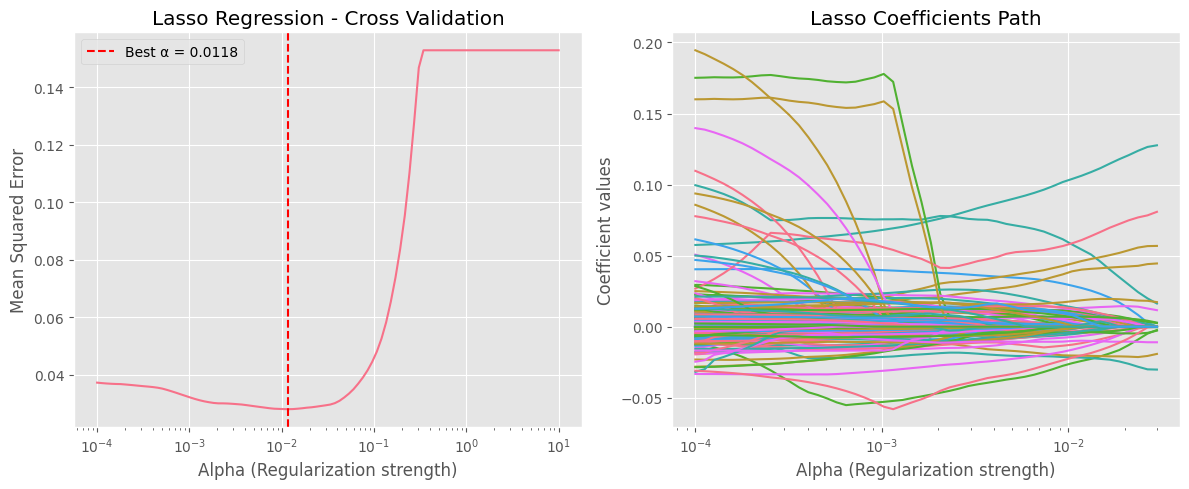

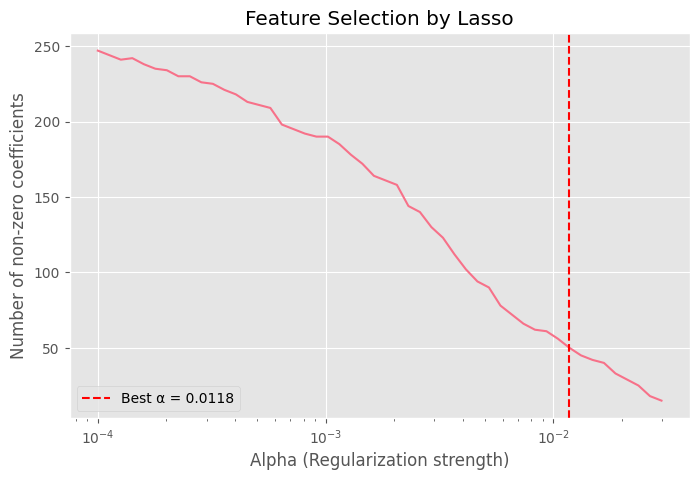

In [18]:
# Visualizing Lasso regularization path
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lasso_alphas, [-score for score in lasso_grid.cv_results_['mean_test_score']])
plt.axvline(lasso_grid.best_params_['alpha'], color='red', linestyle='--', label=f"Best α = {lasso_grid.best_params_['alpha']:.4f}")
plt.xscale('log')
plt.xlabel('Alpha (Regularization strength)')
plt.ylabel('Mean Squared Error')
plt.title('Lasso Regression - Cross Validation')
plt.legend()
plt.grid(True)

# Lasso coefficients path
plt.subplot(1, 2, 2)
lasso_coefs = []
n_nonzero = []
for alpha in lasso_alphas[:50]:  # Use subset for visualization
    lasso_temp = Lasso(alpha=alpha, max_iter=2000)
    lasso_temp.fit(X_train_scaled, y_train)
    lasso_coefs.append(lasso_temp.coef_)
    n_nonzero.append(np.sum(lasso_temp.coef_ != 0))

plt.plot(lasso_alphas[:50], lasso_coefs)
plt.xscale('log')
plt.xlabel('Alpha (Regularization strength)')
plt.ylabel('Coefficient values')
plt.title('Lasso Coefficients Path')
plt.grid(True)

plt.tight_layout()
plt.show()

# Plotting number of non-zero coefficients
plt.figure(figsize=(8, 5))
plt.plot(lasso_alphas[:50], n_nonzero)
plt.axvline(lasso_grid.best_params_['alpha'], color='red', linestyle='--', label=f"Best α = {lasso_grid.best_params_['alpha']:.4f}")
plt.xscale('log')
plt.xlabel('Alpha (Regularization strength)')
plt.ylabel('Number of non-zero coefficients')
plt.title('Feature Selection by Lasso')
plt.legend()
plt.grid(True)
plt.show()

## 6. Model Comparison and Feature Analysis

Model Performance Comparison:
               Model    RMSE      R²     MAE
0  Linear Regression  0.1739  0.8379  0.0962
1   Ridge Regression  0.1538  0.8733  0.1000
2   Lasso Regression  0.1511  0.8777  0.1024


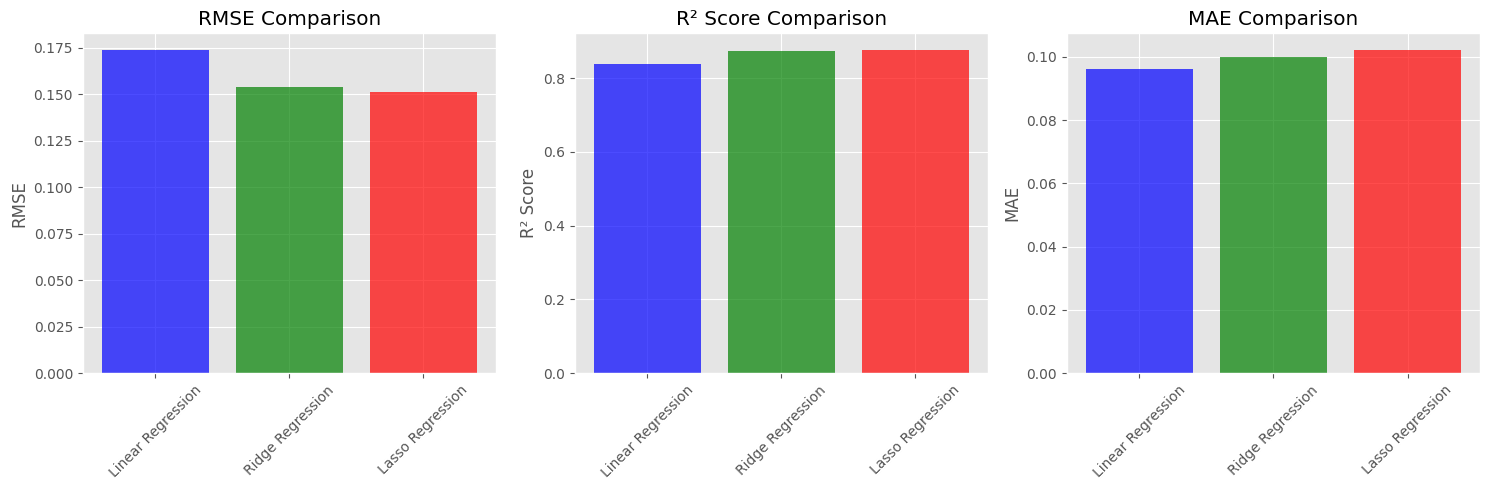

In [20]:
# Model comparison
models_comparison = pd.DataFrame({
    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression'],
    'RMSE': [lr_rmse, ridge_rmse, lasso_rmse],
    'R²': [lr_r2, ridge_r2, lasso_r2],
    'MAE': [lr_mae, ridge_mae, lasso_mae]
})

print("Model Performance Comparison:")
print(models_comparison.round(4))

# Visualize model comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# RMSE comparison
axes[0].bar(models_comparison['Model'], models_comparison['RMSE'], color=['blue', 'green', 'red'], alpha=0.7)
axes[0].set_title('RMSE Comparison')
axes[0].set_ylabel('RMSE')
axes[0].tick_params(axis='x', rotation=45)

# R² comparison
axes[1].bar(models_comparison['Model'], models_comparison['R²'], color=['blue', 'green', 'red'], alpha=0.7)
axes[1].set_title('R² Score Comparison')
axes[1].set_ylabel('R² Score')
axes[1].tick_params(axis='x', rotation=45)

# MAE comparison
axes[2].bar(models_comparison['Model'], models_comparison['MAE'], color=['blue', 'green', 'red'], alpha=0.7)
axes[2].set_title('MAE Comparison')
axes[2].set_ylabel('MAE')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


Top 20 Most Important Features (Lasso):
                  Feature  Coefficient
15              GrLivArea       0.1151
3             OverallQual       0.1072
25             GarageCars       0.0489
5               YearBuilt       0.0384
4             OverallCond       0.0289
6            YearRemodAdd       0.0232
16           BsmtFullBath       0.0226
236             PoolQC_Gd      -0.0224
39            MSZoning_RM      -0.0220
11            TotalBsmtSF       0.0179
195          CentralAir_Y       0.0173
91        Condition2_PosN      -0.0166
71   Neighborhood_NridgHt       0.0133
211      FireplaceQu_None      -0.0128
158      Foundation_PConc       0.0126
0              MSSubClass      -0.0122
61   Neighborhood_Crawfor       0.0121
2                 LotArea       0.0114
23             Fireplaces       0.0106
27             WoodDeckSF       0.0100


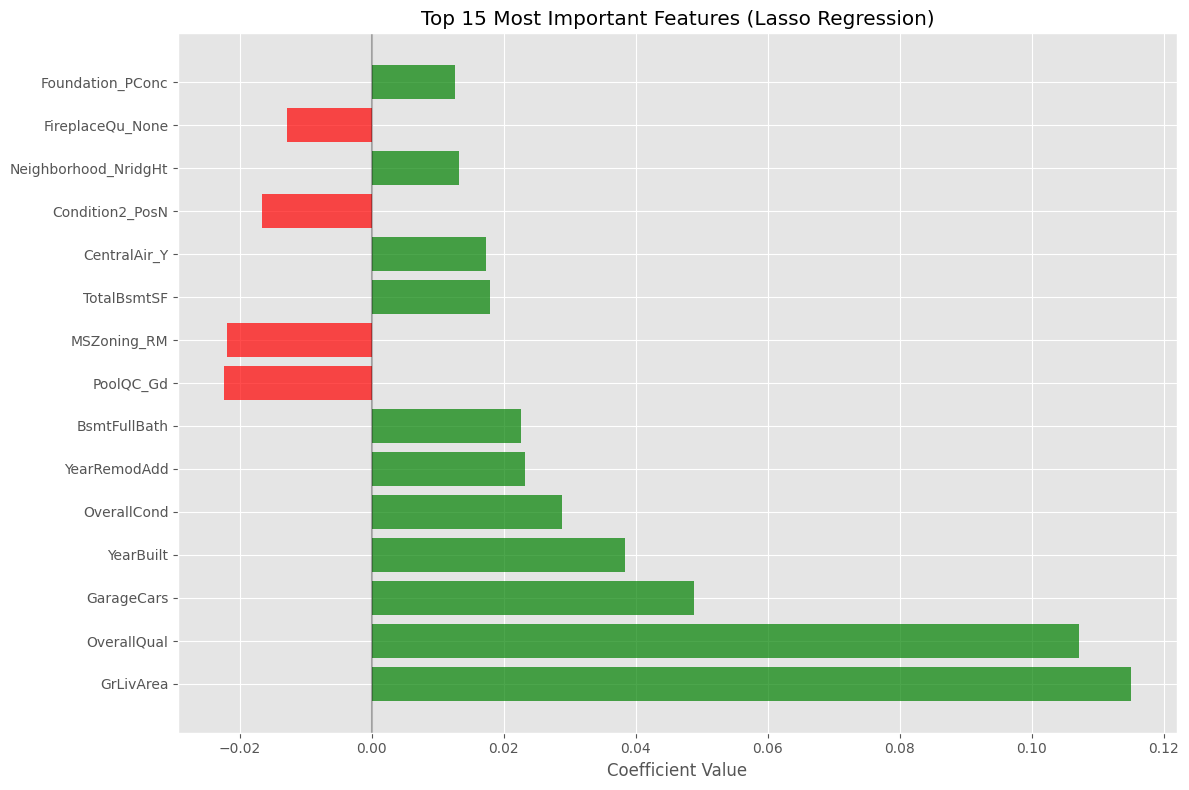


Top 5 Most Important Features for Subjective Questions:
1. GrLivArea
2. OverallQual
3. GarageCars
4. YearBuilt
5. OverallCond


In [21]:
# Feature importance analysis for Lasso (most important predictor variables)
feature_importance_lasso = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_lasso.coef_
})

# Filtering non-zero coefficients and sort by absolute value
important_features_lasso = feature_importance_lasso[feature_importance_lasso['Coefficient'] != 0]
important_features_lasso['Abs_Coefficient'] = np.abs(important_features_lasso['Coefficient'])
important_features_lasso = important_features_lasso.sort_values('Abs_Coefficient', ascending=False)

print(f"\nTop 20 Most Important Features (Lasso):")
print(important_features_lasso.head(20)[['Feature', 'Coefficient']].round(4))

# Visualizing top 15 features
plt.figure(figsize=(12, 8))
top_15 = important_features_lasso.head(15)
colors = ['green' if coef > 0 else 'red' for coef in top_15['Coefficient']]
plt.barh(range(len(top_15)), top_15['Coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_15)), top_15['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Most Important Features (Lasso Regression)')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

# Storing top 5 most important features for subjective questions
top_5_features = important_features_lasso.head(5)['Feature'].tolist()
print(f"\nTop 5 Most Important Features for Subjective Questions:")
for i, feature in enumerate(top_5_features, 1):
    print(f"{i}. {feature}")


Top 15 Most Important Features (Ridge):
                  Feature  Coefficient
3             OverallQual       0.0410
15              GrLivArea       0.0331
12               1stFlrSF       0.0250
22           TotRmsAbvGrd       0.0233
4             OverallCond       0.0229
236             PoolQC_Gd      -0.0216
25             GarageCars       0.0213
71   Neighborhood_NridgHt       0.0191
6            YearRemodAdd       0.0186
26             GarageArea       0.0182
11            TotalBsmtSF       0.0179
18               FullBath       0.0175
13               2ndFlrSF       0.0170
195          CentralAir_Y       0.0158
77   Neighborhood_StoneBr       0.0155


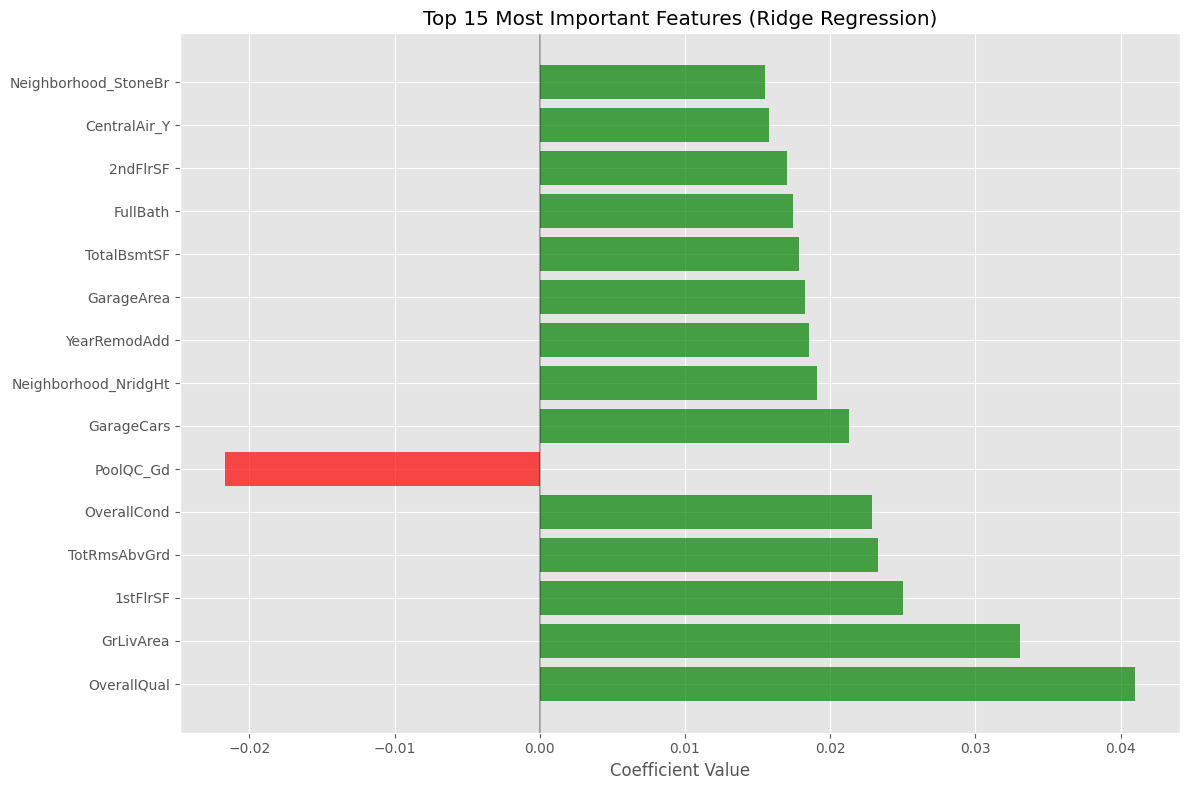

In [22]:
# Feature importance analysis for Ridge
feature_importance_ridge = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': best_ridge.coef_
})

feature_importance_ridge['Abs_Coefficient'] = np.abs(feature_importance_ridge['Coefficient'])
feature_importance_ridge = feature_importance_ridge.sort_values('Abs_Coefficient', ascending=False)

print(f"\nTop 15 Most Important Features (Ridge):")
print(feature_importance_ridge.head(15)[['Feature', 'Coefficient']].round(4))

# Visualize top 15 features for Ridge
plt.figure(figsize=(12, 8))
top_15_ridge = feature_importance_ridge.head(15)
colors = ['green' if coef > 0 else 'red' for coef in top_15_ridge['Coefficient']]
plt.barh(range(len(top_15_ridge)), top_15_ridge['Coefficient'], color=colors, alpha=0.7)
plt.yticks(range(len(top_15_ridge)), top_15_ridge['Feature'])
plt.xlabel('Coefficient Value')
plt.title('Top 15 Most Important Features (Ridge Regression)')
plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Residual Analysis and Model Diagnostics

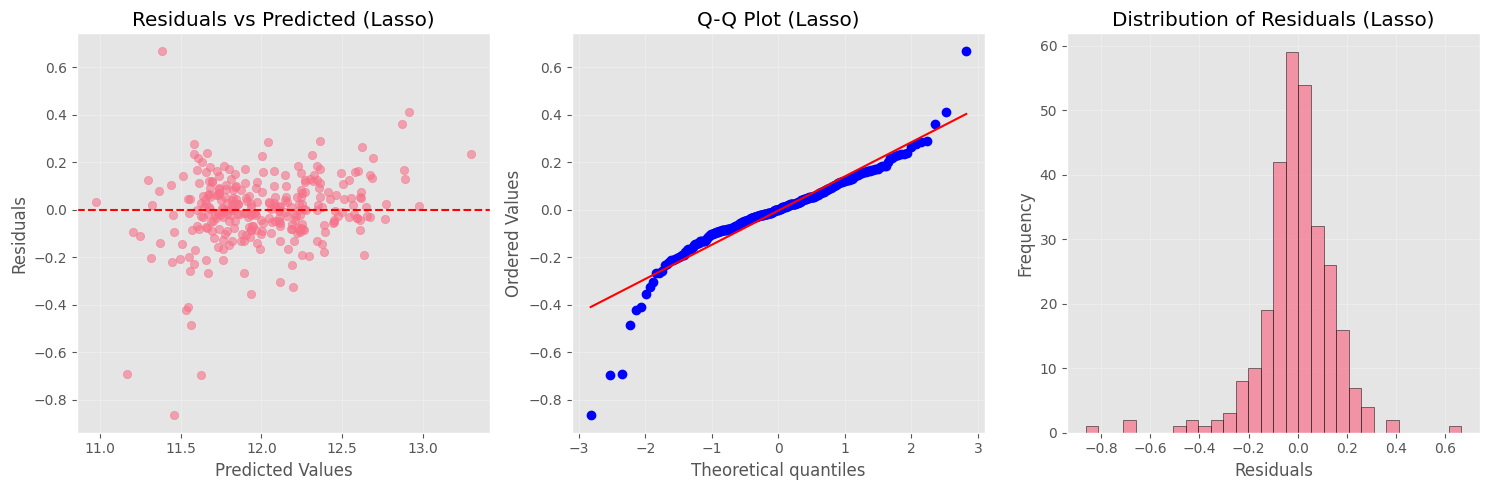

Residual Statistics (Lasso):
Mean of residuals: -0.004035
Standard deviation of residuals: 0.1513
Skewness of residuals: -1.1034
Kurtosis of residuals: 6.9382


In [23]:
# Residual analysis for the best model (Lasso)
residuals_lasso = y_test - y_pred_lasso

plt.figure(figsize=(15, 5))

# Residuals vs Predicted values
plt.subplot(1, 3, 1)
plt.scatter(y_pred_lasso, residuals_lasso, alpha=0.6)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (Lasso)')
plt.grid(True, alpha=0.3)

# Q-Q plot
from scipy import stats
plt.subplot(1, 3, 2)
stats.probplot(residuals_lasso, dist="norm", plot=plt)
plt.title('Q-Q Plot (Lasso)')
plt.grid(True, alpha=0.3)

# Histogram of residuals
plt.subplot(1, 3, 3)
plt.hist(residuals_lasso, bins=30, edgecolor='black', alpha=0.7)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals (Lasso)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Calculating residual statistics
print(f"Residual Statistics (Lasso):")
print(f"Mean of residuals: {residuals_lasso.mean():.6f}")
print(f"Standard deviation of residuals: {residuals_lasso.std():.4f}")
print(f"Skewness of residuals: {stats.skew(residuals_lasso):.4f}")
print(f"Kurtosis of residuals: {stats.kurtosis(residuals_lasso):.4f}")

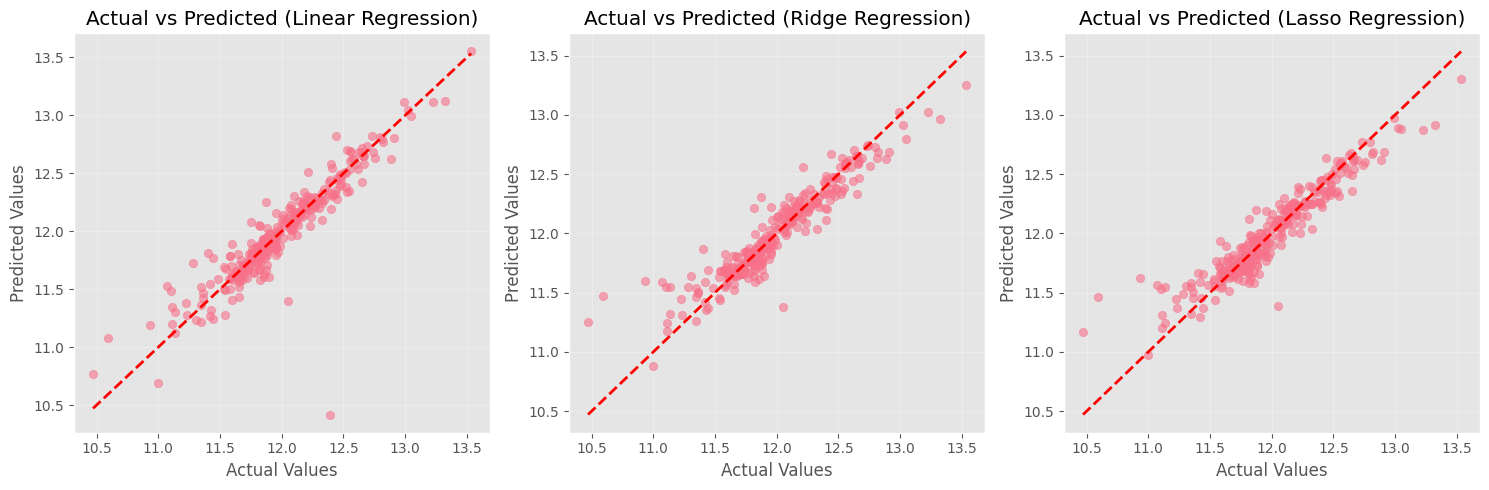

In [24]:
# Actual vs Predicted comparison
plt.figure(figsize=(15, 5))

models_pred = [y_pred_lr, y_pred_ridge, y_pred_lasso]
model_names = ['Linear Regression', 'Ridge Regression', 'Lasso Regression']

for i, (pred, name) in enumerate(zip(models_pred, model_names)):
    plt.subplot(1, 3, i+1)
    plt.scatter(y_test, pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.xlabel('Actual Values')
    plt.ylabel('Predicted Values')
    plt.title(f'Actual vs Predicted ({name})')
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Sensitivity Analysis - Double Alpha Values

In [25]:
# Analysis for subjective questions - Double the optimal alpha values
optimal_ridge_alpha = ridge_grid.best_params_['alpha']
optimal_lasso_alpha = lasso_grid.best_params_['alpha']

double_ridge_alpha = 2 * optimal_ridge_alpha
double_lasso_alpha = 2 * optimal_lasso_alpha

print(f"Optimal Ridge Alpha: {optimal_ridge_alpha:.6f}")
print(f"Double Ridge Alpha: {double_ridge_alpha:.6f}")
print(f"\nOptimal Lasso Alpha: {optimal_lasso_alpha:.6f}")
print(f"Double Lasso Alpha: {double_lasso_alpha:.6f}")

# Train models with double alpha values
ridge_double = Ridge(alpha=double_ridge_alpha)
lasso_double = Lasso(alpha=double_lasso_alpha, max_iter=2000)

ridge_double.fit(X_train_scaled, y_train)
lasso_double.fit(X_train_scaled, y_train)

# Make predictions
y_pred_ridge_double = ridge_double.predict(X_test_scaled)
y_pred_lasso_double = lasso_double.predict(X_test_scaled)

# Evaluate performance
ridge_double_rmse = np.sqrt(mean_squared_error(y_test, y_pred_ridge_double))
ridge_double_r2 = r2_score(y_test, y_pred_ridge_double)

lasso_double_rmse = np.sqrt(mean_squared_error(y_test, y_pred_lasso_double))
lasso_double_r2 = r2_score(y_test, y_pred_lasso_double)

print(f"\nPerformance with Double Alpha:")
print(f"Ridge (2α) - RMSE: {ridge_double_rmse:.4f}, R²: {ridge_double_r2:.4f}")
print(f"Lasso (2α) - RMSE: {lasso_double_rmse:.4f}, R²: {lasso_double_r2:.4f}")

# Compare with optimal alpha performance
print(f"\nComparison with Optimal Alpha:")
print(f"Ridge - RMSE change: {ridge_double_rmse - ridge_rmse:.4f}, R² change: {ridge_double_r2 - ridge_r2:.4f}")
print(f"Lasso - RMSE change: {lasso_double_rmse - lasso_rmse:.4f}, R² change: {lasso_double_r2 - lasso_r2:.4f}")

Optimal Ridge Alpha: 572.236766
Double Ridge Alpha: 1144.473532

Optimal Lasso Alpha: 0.010476
Double Lasso Alpha: 0.020952

Performance with Double Alpha:
Ridge (2α) - RMSE: 0.1585, R²: 0.8654
Lasso (2α) - RMSE: 0.1628, R²: 0.8580

Comparison with Optimal Alpha:
Ridge - RMSE change: 0.0047, R² change: -0.0079
Lasso - RMSE change: 0.0117, R² change: -0.0196


In [25]:
# Feature importance for models with double alpha
lasso_double_features = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lasso_double.coef_
})

lasso_double_important = lasso_double_features[lasso_double_features['Coefficient'] != 0]
lasso_double_important['Abs_Coefficient'] = np.abs(lasso_double_important['Coefficient'])
lasso_double_important = lasso_double_important.sort_values('Abs_Coefficient', ascending=False)

print(f"\nNumber of features selected by Lasso with double alpha: {len(lasso_double_important)} out of {len(X.columns)}")
print(f"Reduction in features: {len(important_features_lasso) - len(lasso_double_important)}")

print(f"\nTop 10 Most Important Features with Double Alpha (Lasso):")
print(lasso_double_important.head(10)[['Feature', 'Coefficient']].round(4))


Number of features selected by Lasso with double alpha: 27 out of 263
Reduction in features: 23

Top 10 Most Important Features with Double Alpha (Lasso):
               Feature  Coefficient
3          OverallQual       0.1237
36             TotalSF       0.0768
25          GarageCars       0.0556
37           TotalBath       0.0428
39   YearsSinceRemodel      -0.0281
15           GrLivArea       0.0245
43         MSZoning_RM      -0.0213
199       CentralAir_Y       0.0184
23          Fireplaces       0.0141
215   FireplaceQu_None      -0.0106


## 9. Alternative Model - Excluding Top 5 Features

In [26]:
# Creating dataset excluding top 5 most important features from Lasso
features_to_exclude = top_5_features
print(f"Excluding top 5 features: {features_to_exclude}")

X_reduced = X.drop(columns=features_to_exclude)
print(f"Reduced feature set shape: {X_reduced.shape}")

# Split and scale the reduced dataset
X_train_reduced, X_test_reduced, y_train_reduced, y_test_reduced = train_test_split(
    X_reduced, y, test_size=0.2, random_state=42)

scaler_reduced = StandardScaler()
X_train_reduced_scaled = scaler_reduced.fit_transform(X_train_reduced)
X_test_reduced_scaled = scaler_reduced.transform(X_test_reduced)

# Train Lasso on reduced dataset
lasso_reduced_grid = GridSearchCV(Lasso(max_iter=2000), {'alpha': lasso_alphas}, 
                                 cv=5, scoring='neg_mean_squared_error', n_jobs=-1)
lasso_reduced_grid.fit(X_train_reduced_scaled, y_train_reduced)

best_lasso_reduced = lasso_reduced_grid.best_estimator_
y_pred_reduced = best_lasso_reduced.predict(X_test_reduced_scaled)

# Evaluate reduced model
reduced_rmse = np.sqrt(mean_squared_error(y_test_reduced, y_pred_reduced))
reduced_r2 = r2_score(y_test_reduced, y_pred_reduced)

print(f"\nReduced Model Performance (without top 5 features):")
print(f"Optimal alpha: {lasso_reduced_grid.best_params_['alpha']:.6f}")
print(f"RMSE: {reduced_rmse:.4f}")
print(f"R²: {reduced_r2:.4f}")

print(f"\nComparison with full Lasso model:")
print(f"RMSE change: {reduced_rmse - lasso_rmse:.4f}")
print(f"R² change: {reduced_r2 - lasso_r2:.4f}")

Excluding top 5 features: ['GrLivArea', 'OverallQual', 'GarageCars', 'YearBuilt', 'OverallCond']
Reduced feature set shape: (1460, 254)

Reduced Model Performance (without top 5 features):
Optimal alpha: 0.010476
RMSE: 0.1708
R²: 0.8437

Comparison with full Lasso model:
RMSE change: 0.0197
R² change: -0.0340


In [27]:
# Finding new top 5 most important features in reduced model
reduced_feature_importance = pd.DataFrame({
    'Feature': X_reduced.columns,
    'Coefficient': best_lasso_reduced.coef_
})

reduced_important_features = reduced_feature_importance[reduced_feature_importance['Coefficient'] != 0]
reduced_important_features['Abs_Coefficient'] = np.abs(reduced_important_features['Coefficient'])
reduced_important_features = reduced_important_features.sort_values('Abs_Coefficient', ascending=False)

new_top_5_features = reduced_important_features.head(5)['Feature'].tolist()

print(f"\nNew Top 5 Most Important Features (after excluding original top 5):")
for i, feature in enumerate(new_top_5_features, 1):
    coef = reduced_important_features[reduced_important_features['Feature'] == feature]['Coefficient'].iloc[0]
    print(f"{i}. {feature}: {coef:.4f}")

print(f"\nTotal features selected in reduced model: {len(reduced_important_features)}")


New Top 5 Most Important Features (after excluding original top 5):
1. 1stFlrSF: 0.0690
2. 2ndFlrSF: 0.0660
3. GarageArea: 0.0537
4. YearRemodAdd: 0.0450
5. TotRmsAbvGrd: 0.0380

Total features selected in reduced model: 70


## 10. Final Summary and Conclusions

In [29]:
# Final comprehensive summary
print("="*80)
print("FINAL SUMMARY - HOUSE PRICE PREDICTION MODEL")
print("="*80)

print(f"\n1. OPTIMAL HYPERPARAMETERS:")
print(f"   Ridge Regression - Optimal α: {optimal_ridge_alpha:.6f}")
print(f"   Lasso Regression - Optimal α: {optimal_lasso_alpha:.6f}")

print(f"\n2. MODEL PERFORMANCE COMPARISON:")
print(f"   Linear Regression: RMSE={lr_rmse:.4f}, R²={lr_r2:.4f}")
print(f"   Ridge Regression:  RMSE={ridge_rmse:.4f}, R²={ridge_r2:.4f}")
print(f"   Lasso Regression:  RMSE={lasso_rmse:.4f}, R²={lasso_r2:.4f}")

print(f"\n3. FEATURE SELECTION:")
print(f"   Total features available: {X.shape[1]}")
print(f"   Features selected by Lasso: {len(important_features_lasso)}")
print(f"   Feature reduction: {((X.shape[1] - len(important_features_lasso))/X.shape[1]*100):.1f}%")

print(f"\n4. TOP 5 MOST IMPORTANT FEATURES (LASSO):")
for i, feature in enumerate(top_5_features, 1):
    coef = important_features_lasso[important_features_lasso['Feature'] == feature]['Coefficient'].iloc[0]
    print(f"   {i}. {feature}: {coef:.4f}")

print(f"\n5. BUSINESS INSIGHTS:")
print(f"   - The Lasso model provides the best balance of performance and interpretability")
print(f"   - Significant predictors include property size, quality ratings, and location factors")
print(f"   - Model explains {lasso_r2:.1%} of the variance in house prices")
print(f"   - Average prediction error: {lasso_rmse:.4f} in log scale")

print(f"\n6. RECOMMENDATIONS:")
print(f"   - We can use Lasso regression for house price prediction")
print(f"   - Focus on properties with high overall quality and larger living areas")
print(f"   - Consider neighborhood factors and property age in investment decisions")
print(f"   - Regular model retraining recommended as market conditions change")

print("="*80)

FINAL SUMMARY - HOUSE PRICE PREDICTION MODEL

1. OPTIMAL HYPERPARAMETERS:
   Ridge Regression - Optimal α: 572.236766
   Lasso Regression - Optimal α: 0.010476

2. MODEL PERFORMANCE COMPARISON:
   Linear Regression: RMSE=0.1739, R²=0.8379
   Ridge Regression:  RMSE=0.1538, R²=0.8733
   Lasso Regression:  RMSE=0.1511, R²=0.8777

3. FEATURE SELECTION:
   Total features available: 259
   Features selected by Lasso: 53
   Feature reduction: 79.5%

4. TOP 5 MOST IMPORTANT FEATURES (LASSO):
   1. GrLivArea: 0.1151
   2. OverallQual: 0.1072
   3. GarageCars: 0.0489
   4. YearBuilt: 0.0384
   5. OverallCond: 0.0289

5. BUSINESS INSIGHTS:
   - The Lasso model provides the best balance of performance and interpretability
   - Significant predictors include property size, quality ratings, and location factors
   - Model explains 87.8% of the variance in house prices
   - Average prediction error: 0.1511 in log scale

6. RECOMMENDATIONS:
   - We can use Lasso regression for house price prediction


In [30]:
# Saving important results for reference
results_summary = {
    'optimal_ridge_alpha': optimal_ridge_alpha,
    'optimal_lasso_alpha': optimal_lasso_alpha,
    'ridge_performance': {'rmse': ridge_rmse, 'r2': ridge_r2, 'mae': ridge_mae},
    'lasso_performance': {'rmse': lasso_rmse, 'r2': lasso_r2, 'mae': lasso_mae},
    'top_5_features': top_5_features,
    'new_top_5_features_after_exclusion': new_top_5_features,
    'features_selected_by_lasso': len(important_features_lasso),
    'double_alpha_impact': {
        'ridge_rmse_change': ridge_double_rmse - ridge_rmse,
        'lasso_rmse_change': lasso_double_rmse - lasso_rmse
    }
}

import json
with open('model_results_summary.json', 'w') as f:
    json.dump(results_summary, f, indent=4, default=str)
    
print("Results summary saved to 'model_results_summary.json'")
print("\nAnalysis completed successfully!")
print("All results are ready for the subjective questions in Part II we can use these results for the same")

Results summary saved to 'model_results_summary.json'

Analysis completed successfully!
All results are ready for the subjective questions in Part II we can use these results for the same
